# Pet Classification - CV 2025

## Assignment Overview

This notebook implements two alternative computer vision pipelines for pet breed classification:

1. **Neural Pipeline**: U-Net CNN with dual heads (segmentation + classification)
2. **Traditional Pipeline**: Bag-of-Features with SIFT features + MLP classifier

**Dataset:** Oxford-IIIT Pet Dataset (6 breeds: Abyssinian, Bengal, Birman, Boxer, English Cocker Spaniel, German Shorthaired)

**Requirements:**
- Use only NumPy, Matplotlib, OpenCV, and PyTorch+TorchVision
- No pre-trained models or ready-made BoF implementations
- Custom implementations of evaluation metrics
- Proper train/val/test split (80/20 split of trainval, fixed seed)

In [2]:
# Install required packages
!pip install numpy matplotlib opencv-python torch torchvision

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import functional as F
import os
from collections import defaultdict
import random

def shuffle_split(indices, test_frac, seed):
    rng = np.random.default_rng(seed)
    idx = np.array(indices, dtype=np.int64)
    rng.shuffle(idx)
    n = int(len(idx) * (1 - test_frac))
    return idx[:n].tolist(), idx[n:].tolist()

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Matplotlib settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

Using device: cpu


## Part 1: Dataset Loading and Preprocessing

### 1. Load Oxford-IIIT Pet Dataset

The dataset is **downloaded automatically** when run (e.g. on Colab) via `download=True`. The train/val split for the 6 classes is **reproducible** using a fixed seed (`RANDOM_SEED`). We load both category labels and segmentation masks.

In [4]:
# Define the 6 breeds we'll use
TARGET_BREEDS = ['Abyssinian', 'Bengal', 'Birman', 'Boxer', 'English Cocker Spaniel', 'German Shorthaired']
NUM_CLASSES = len(TARGET_BREEDS)
IMAGE_SIZE = 128

# Dataset: automatic download and fixed seed for reproducible split
import os

if not os.path.exists('./oxford-iiit-pet') and os.path.exists('./pets'):
    try:
        os.symlink('./pets', './oxford-iiit-pet', target_is_directory=True)
        print("Created symlink: oxford-iiit-pet -> pets")
    except (OSError, NotImplementedError):
        pass

print("Loading Oxford-IIIT Pet Dataset (downloads automatically if missing)...")
full_dataset = datasets.OxfordIIITPet(
    root='./',
    split='trainval',
    target_types=("category", "segmentation"),
    download=True  # Required: download dataset automatically when run (e.g. Colab)
)

print(f"Total images in dataset: {len(full_dataset)}")
print(f"Total classes in dataset: {len(full_dataset.classes)}")
print(f"Classes: {full_dataset.classes[:10]}...")  # Show first 10

# Find indices for our 6 target breeds
class_to_idx = full_dataset.class_to_idx
breed_indices = {}
for breed in TARGET_BREEDS:
    if breed in class_to_idx:
        breed_indices[breed] = class_to_idx[breed]
        print(f"{breed}: index {class_to_idx[breed]}")
    else:
        print(f"WARNING: {breed} not found in dataset!")

# Create mapping from original class index to our 6-class index
original_to_our_class = {breed_indices[breed]: idx for idx, breed in enumerate(TARGET_BREEDS)}
print(f"\nOriginal to our class mapping: {original_to_our_class}")

Loading Oxford-IIIT Pet Dataset (downloads automatically if missing)...


100.0%
100.0%


Total images in dataset: 3680
Total classes in dataset: 37
Classes: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair']...
Abyssinian: index 0
Bengal: index 5
Birman: index 6
Boxer: index 8
English Cocker Spaniel: index 12
German Shorthaired: index 14

Original to our class mapping: {0: 0, 5: 1, 6: 2, 8: 3, 12: 4, 14: 5}


### 2. Filter Dataset to 6 Breeds and Create Custom Dataset Class

In [5]:
class PetDataset(Dataset):
    """
    Custom dataset class that filters to 6 breeds and preprocesses images/masks.
    """
    def __init__(self, full_dataset, breed_indices, original_to_our_class, image_size=256, transform=None):
        self.full_dataset = full_dataset
        self.breed_indices = breed_indices
        self.original_to_our_class = original_to_our_class
        self.image_size = image_size
        self.transform = transform

        # Filter indices to only include our 6 breeds
        self.indices = []
        for idx in range(len(full_dataset)):
            image, (category, segmentation) = full_dataset[idx]
            if category in breed_indices.values():
                self.indices.append(idx)

        print(f"Filtered dataset: {len(self.indices)} images from {len(full_dataset)} total")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Get original index
        original_idx = self.indices[idx]
        image, (category, segmentation) = self.full_dataset[original_idx]

        # Convert PIL to numpy
        image = np.array(image)
        segmentation = np.array(segmentation)

        # Resize image to common size
        image = cv2.resize(image, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)

        # Resize mask with nearest neighbor to preserve labels
        segmentation = cv2.resize(segmentation, (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        # Convert mask: background=0, foreground=1, boundary=255 (for ignore_index)
        # Original: 1=foreground, 2=background, 3=boundary
        mask = segmentation.copy()
        mask[segmentation == 2] = 0  # background -> 0
        mask[segmentation == 1] = 1   # foreground -> 1
        mask[segmentation == 3] = 255 # boundary -> 255 (ignore)

        # Convert category to our 6-class index
        our_class = self.original_to_our_class[category]

        # Apply transforms if provided
        if self.transform:
            image = self.transform(image)

        # Convert to tensors
        # Image: (H, W, C) -> (C, H, W) and normalize to [0, 1]
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).long()
        our_class = torch.tensor(our_class, dtype=torch.long)

        return image, (our_class, mask)

# Create filtered dataset
filtered_dataset = PetDataset(full_dataset, breed_indices, original_to_our_class, image_size=IMAGE_SIZE)
print(f"Filtered dataset size: {len(filtered_dataset)}")

Filtered dataset: 596 images from 3680 total
Filtered dataset size: 596


### 3. Split Dataset into Train/Val/Test

According to the assignment, the official dataset provides only "trainval". We need to split trainval into train (80%) and val (20%) with fixed seed. The test set should come from the official test split (if available) or be held out from trainval.

In [6]:
# First, try to load the test set
try:
    test_dataset_full = datasets.OxfordIIITPet(
        root='./',
        split='test',
        target_types=("category", "segmentation"),
        download=True  # Same root as trainval; skip if already downloaded
    )

    # Filter test set to our 6 breeds
    test_indices = []
    for idx in range(len(test_dataset_full)):
        image, (category, segmentation) = test_dataset_full[idx]
        if category in breed_indices.values():
            test_indices.append(idx)

    print(f"Found {len(test_indices)} test images")

    # Create test dataset
    test_dataset = PetDataset(test_dataset_full, breed_indices, original_to_our_class, image_size=IMAGE_SIZE)

    # Use filtered_dataset as trainval
    trainval_dataset = filtered_dataset

except:
    print("Test split not available or error loading. Splitting trainval into train/val/test...")
    # 60/20/20 split with fixed seed (NumPy only, no scikit-learn)
    trainval_indices = list(range(len(filtered_dataset)))
    rng = np.random.default_rng(RANDOM_SEED)
    idx = np.array(trainval_indices, dtype=np.int64)
    rng.shuffle(idx)
    n = len(idx)
    train_indices = idx[:int(0.6*n)].tolist()
    val_indices = idx[int(0.6*n):int(0.8*n)].tolist()
    test_indices = idx[int(0.8*n):].tolist()
    trainval_dataset = Subset(filtered_dataset, train_indices + val_indices)
    test_dataset = Subset(filtered_dataset, test_indices)
    print(f"Split trainval into: train={len(train_indices)}, val={len(val_indices)}, test={len(test_indices)}")

# Split trainval into train (80%) and val (20%) with fixed seed
trainval_indices = list(range(len(trainval_dataset)))
train_indices, val_indices = shuffle_split(trainval_indices, test_frac=0.2, seed=RANDOM_SEED)

train_dataset = Subset(trainval_dataset, train_indices)
val_dataset = Subset(trainval_dataset, val_indices)

print(f"\nFinal splits:")
print(f"Train: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")

# Verify no overlap
train_set = set(train_indices)
val_set = set(val_indices)
if isinstance(test_dataset, Subset):
    test_set = set(test_dataset.indices)
else:
    test_set = set(range(len(test_dataset)))

print(f"\nOverlap check:")
print(f"Train-Val overlap: {len(train_set & val_set)}")
if isinstance(test_dataset, Subset):
    print(f"Train-Test overlap: {len(train_set & test_set)}")
    print(f"Val-Test overlap: {len(val_set & test_set)}")

Found 597 test images
Filtered dataset: 597 images from 3669 total

Final splits:
Train: 476 images
Val: 120 images
Test: 597 images

Overlap check:
Train-Val overlap: 0


### 4. Visualize Dataset Samples

Let's visualize some samples to understand the data format.

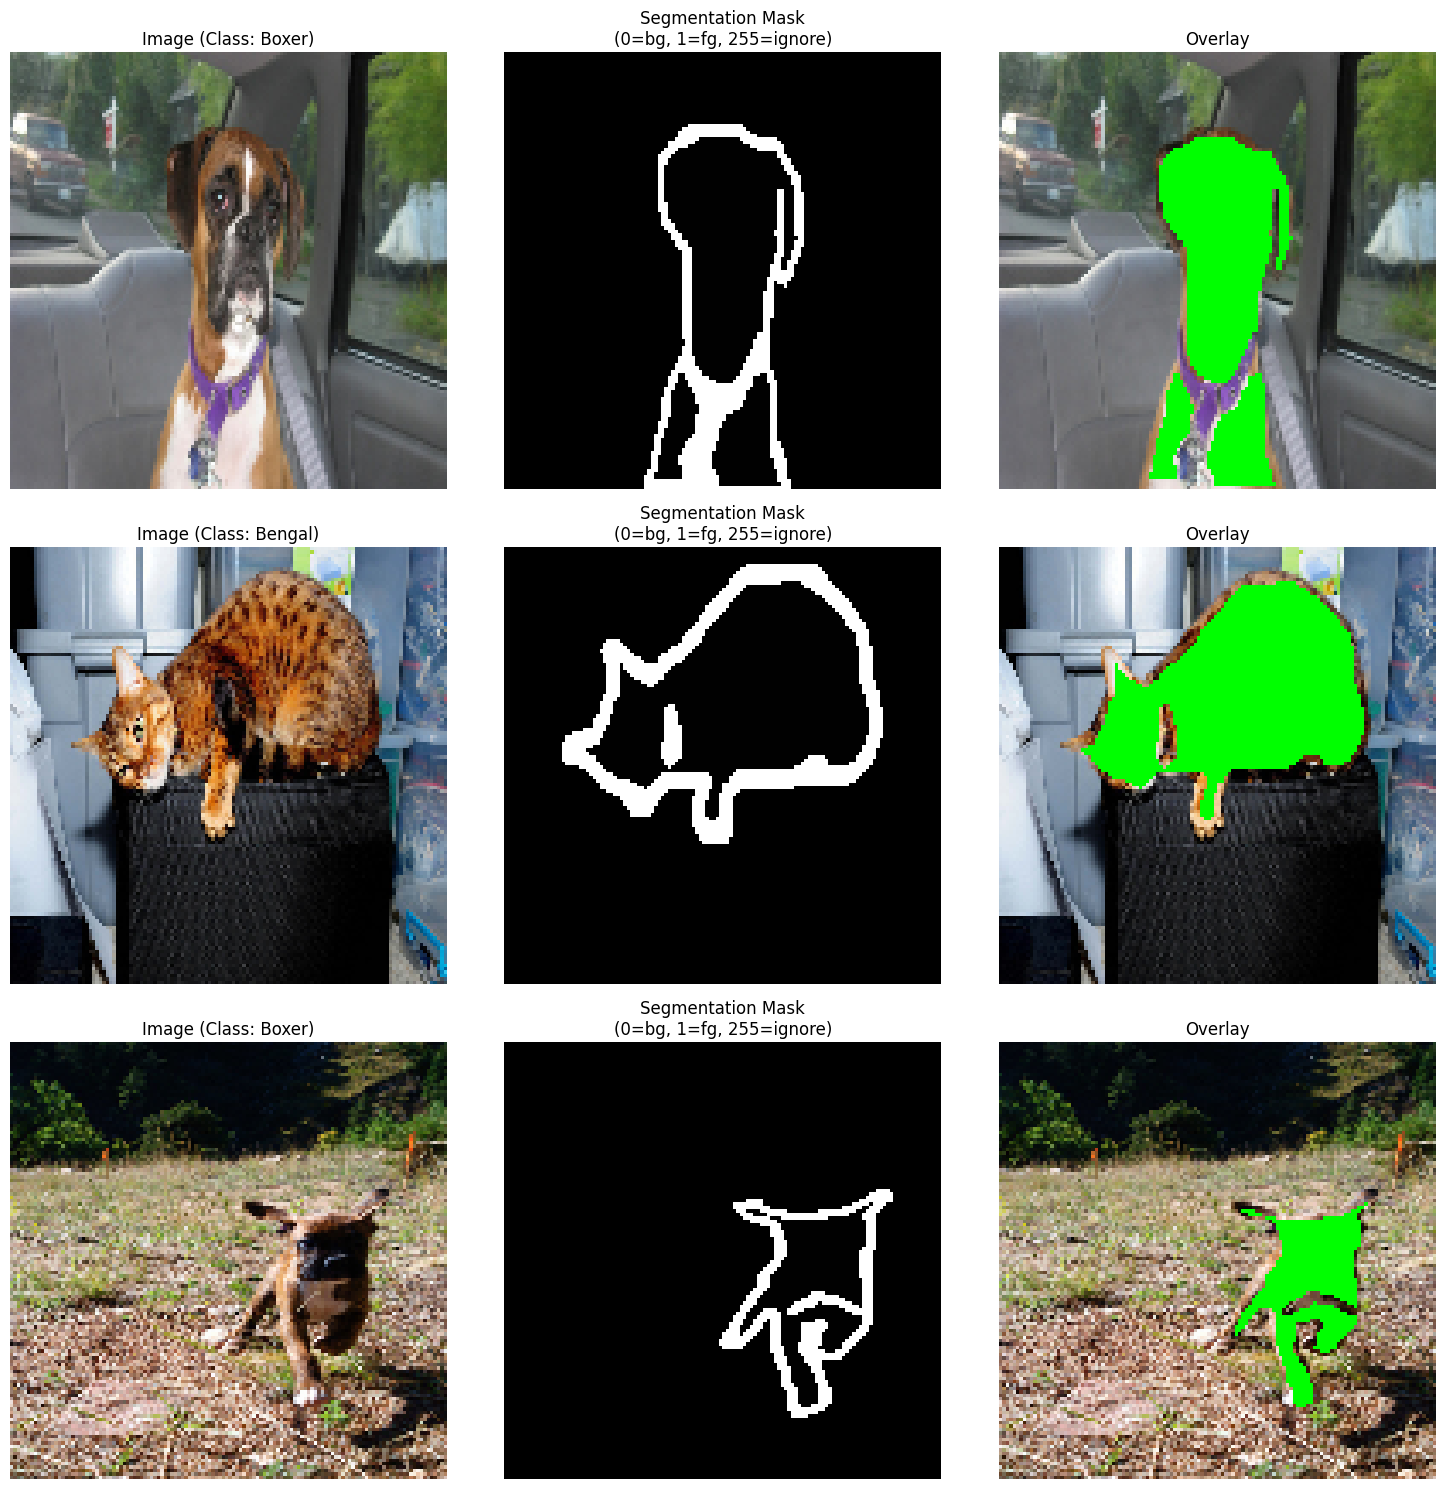


Mask value distribution:
Background (0): 12729 pixels
Foreground (1): 2429 pixels
Boundary/Ignore (255): 1226 pixels
Total pixels: 16384


In [7]:
# Visualize a few samples
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i in range(3):
    idx = i * 50  # Sample different images
    image, (category, mask) = train_dataset[idx]

    # Convert image back to numpy for visualization
    img_np = image.permute(1, 2, 0).numpy()
    mask_np = mask.numpy()

    # Show original image
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f'Image (Class: {TARGET_BREEDS[category]})')
    axes[i, 0].axis('off')

    # Show mask
    axes[i, 1].imshow(mask_np, vmin=0, vmax=255)
    axes[i, 1].set_title('Segmentation Mask\n(0=bg, 1=fg, 255=ignore)')
    axes[i, 1].axis('off')

    # Show overlay
    overlay = img_np.copy()
    # Highlight foreground in green
    overlay[mask_np == 1] = [0, 1, 0]  # Green for foreground
    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title('Overlay')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# Print mask statistics
sample_image, (sample_category, sample_mask) = train_dataset[0]
mask_np = sample_mask.numpy()
print(f"\nMask value distribution:")
print(f"Background (0): {np.sum(mask_np == 0)} pixels")
print(f"Foreground (1): {np.sum(mask_np == 1)} pixels")
print(f"Boundary/Ignore (255): {np.sum(mask_np == 255)} pixels")
print(f"Total pixels: {mask_np.size}")

## Part Α) Neural Pipeline: U-Net with Dual Heads

We'll implement a U-Net with encoder-decoder architecture for segmentation and a parallel classification head. The network is trained jointly with combined loss: λ * segmentation_loss + classification_loss.

### 1. U-Net Architecture

In [8]:
class UNetDualHead(nn.Module):
    """
    U-Net architecture with dual heads. base_channels=32 for faster training (lighter model).
    1. Segmentation head (decoder) for 2-class segmentation
    2. Classification head for 6-class classification
    """
    def __init__(self, in_channels=3, num_seg_classes=2, num_cls_classes=6, base_channels=32):
        super(UNetDualHead, self).__init__()
        c1, c2, c3, c4, c5 = base_channels, base_channels*2, base_channels*4, base_channels*8, base_channels*16

        # Encoder (downsampling path)
        self.enc1 = self._conv_block(in_channels, c1)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = self._conv_block(c1, c2)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = self._conv_block(c2, c3)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = self._conv_block(c3, c4)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self._conv_block(c4, c5)

        # Decoder (upsampling path) for segmentation
        self.up4 = nn.ConvTranspose2d(c5, c4, 2, stride=2)
        self.dec4 = self._conv_block(c4 * 2, c4)  # skip + up

        self.up3 = nn.ConvTranspose2d(c4, c3, 2, stride=2)
        self.dec3 = self._conv_block(c3 * 2, c3)

        self.up2 = nn.ConvTranspose2d(c3, c2, 2, stride=2)
        self.dec2 = self._conv_block(c2 * 2, c2)

        self.up1 = nn.ConvTranspose2d(c2, c1, 2, stride=2)
        self.dec1 = self._conv_block(c1 * 2, c1)

        # Segmentation head
        self.seg_head = nn.Conv2d(c1, num_seg_classes, 1)

        # Classification head (from bottleneck features)
        self.cls_pool = nn.AdaptiveAvgPool2d(1)
        self.cls_fc = nn.Linear(c5, num_cls_classes)

    def _conv_block(self, in_channels, out_channels):
        """Convolution block: Conv2d -> BatchNorm -> ReLU -> Conv2d -> BatchNorm -> ReLU"""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        enc3 = self.enc3(self.pool2(enc2))
        enc4 = self.enc4(self.pool3(enc3))

        # Bottleneck
        bottleneck = self.bottleneck(self.pool4(enc4))

        # Classification head (from bottleneck)
        cls_features = self.cls_pool(bottleneck).view(bottleneck.size(0), -1)
        cls_output = self.cls_fc(cls_features)

        # Decoder (segmentation head)
        dec4 = self.up4(bottleneck)
        dec4 = torch.cat([dec4, enc4], dim=1)
        dec4 = self.dec4(dec4)

        dec3 = self.up3(dec4)
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.dec3(dec3)

        dec2 = self.up2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.dec2(dec2)

        dec1 = self.up1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.dec1(dec1)

        # Segmentation output
        seg_output = self.seg_head(dec1)

        return seg_output, cls_output

# Test the model
model = UNetDualHead(in_channels=3, num_seg_classes=2, num_cls_classes=NUM_CLASSES)
test_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
seg_out, cls_out = model(test_input)
print(f"Model test:")
print(f"Input shape: {test_input.shape}")
print(f"Segmentation output shape: {seg_out.shape}")  # Should be (1, 2, 256, 256)
print(f"Classification output shape: {cls_out.shape}")  # Should be (1, 6)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model test:
Input shape: torch.Size([1, 3, 128, 128])
Segmentation output shape: torch.Size([1, 2, 128, 128])
Classification output shape: torch.Size([1, 6])
Total parameters: 7,769,096


### 2. Custom Evaluation Metrics

We need to implement our own evaluation metrics: mIoU (mean Intersection over Union) for segmentation, and Classification Accuracy (CCR) and Confusion Matrix for classification.

In [9]:
def compute_miou(pred_masks, true_masks, num_classes=2, ignore_index=255):
    """
    Compute mean IoU for segmentation.
    pred_masks: (N, H, W) predicted class indices
    true_masks: (N, H, W) ground truth class indices
    """
    ious = []

    for class_id in range(num_classes):
        # Create binary masks for this class
        pred_binary = (pred_masks == class_id)
        true_binary = (true_masks == class_id)

        # Ignore pixels with ignore_index
        valid_mask = (true_masks != ignore_index)
        pred_binary = pred_binary & valid_mask
        true_binary = true_binary & valid_mask

        # Compute intersection and union
        intersection = (pred_binary & true_binary).sum().item()
        union = (pred_binary | true_binary).sum().item()

        if union == 0:
            iou = 1.0 if intersection == 0 else 0.0
        else:
            iou = intersection / union

        ious.append(iou)

    return np.mean(ious), ious

def compute_confusion_matrix(pred_labels, true_labels, num_classes):
    """
    Compute confusion matrix.
    pred_labels: (N,) predicted class indices
    true_labels: (N,) ground truth class indices
    """
    cm = np.zeros((num_classes, num_classes), dtype=np.int32)

    for i in range(len(pred_labels)):
        cm[true_labels[i], pred_labels[i]] += 1

    return cm

def compute_accuracy(pred_labels, true_labels):
    """
    Compute classification accuracy (CCR).
    """
    return (pred_labels == true_labels).sum().item() / len(pred_labels)

# Test the metrics
test_pred_masks = torch.randint(0, 2, (2, 256, 256))
test_true_masks = torch.randint(0, 2, (2, 256, 256))
test_true_masks[0, 100:150, 100:150] = 255  # Add some ignore pixels

mIoU, per_class_IoU = compute_miou(test_pred_masks.numpy(), test_true_masks.numpy())
print(f"Test mIoU: {mIoU:.4f}")
print(f"Per-class IoU: {per_class_IoU}")

test_pred_labels = torch.tensor([0, 1, 2, 0, 1])
test_true_labels = torch.tensor([0, 1, 2, 1, 1])
cm = compute_confusion_matrix(test_pred_labels.numpy(), test_true_labels.numpy(), NUM_CLASSES)
acc = compute_accuracy(test_pred_labels.numpy(), test_true_labels.numpy())
print(f"\nTest accuracy: {acc:.4f}")
print(f"Confusion matrix:\n{cm}")

Test mIoU: 0.3333
Per-class IoU: [0.33266212737689943, 0.3338927912807443]

Test accuracy: 0.8000
Confusion matrix:
[[1 0 0 0 0 0]
 [1 2 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


### 3. Training Function

In [10]:
def train_epoch(model, dataloader, criterion_seg, criterion_cls, optimizer, device, lambda_weight=1.0, scaler=None):
    """Train for one epoch. Uses AMP (mixed precision) on CUDA when scaler is provided."""
    model.train()
    total_loss = 0.0
    seg_loss_total = 0.0
    cls_loss_total = 0.0
    use_amp = scaler is not None and device.type == 'cuda'

    for images, (labels, masks) in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                seg_pred, cls_pred = model(images)
                seg_loss = criterion_seg(seg_pred, masks)
                cls_loss = criterion_cls(cls_pred, labels)
                loss = lambda_weight * seg_loss + cls_loss
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            seg_pred, cls_pred = model(images)
            seg_loss = criterion_seg(seg_pred, masks)
            cls_loss = criterion_cls(cls_pred, labels)
            loss = lambda_weight * seg_loss + cls_loss
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        seg_loss_total += seg_loss.item()
        cls_loss_total += cls_loss.item()

    return total_loss / len(dataloader), seg_loss_total / len(dataloader), cls_loss_total / len(dataloader)

def validate(model, dataloader, criterion_seg, criterion_cls, device, lambda_weight=1.0):
    """Validate the model. Uses AMP on CUDA for speed."""
    model.eval()
    total_loss = 0.0
    seg_loss_total = 0.0
    cls_loss_total = 0.0
    all_seg_preds = []
    all_seg_trues = []
    all_cls_preds = []
    all_cls_trues = []
    use_amp = device.type == 'cuda'
    with torch.no_grad():
        for images, (labels, masks) in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
                seg_pred, cls_pred = model(images)
                seg_loss = criterion_seg(seg_pred, masks)
                cls_loss = criterion_cls(cls_pred, labels)
                loss = lambda_weight * seg_loss + cls_loss
            total_loss += loss.item()
            seg_loss_total += seg_loss.item()
            cls_loss_total += cls_loss.item()
            seg_pred_classes = seg_pred.argmax(dim=1).cpu().numpy()
            seg_true = masks.cpu().numpy()
            all_seg_preds.append(seg_pred_classes)
            all_seg_trues.append(seg_true)
            cls_pred_classes = cls_pred.argmax(dim=1).cpu().numpy()
            cls_true = labels.cpu().numpy()
            all_cls_preds.append(cls_pred_classes)
            all_cls_trues.append(cls_true)

    # Compute metrics
    all_seg_preds = np.concatenate(all_seg_preds, axis=0)
    all_seg_trues = np.concatenate(all_seg_trues, axis=0)
    all_cls_preds = np.concatenate(all_cls_preds, axis=0)
    all_cls_trues = np.concatenate(all_cls_trues, axis=0)

    mIoU, per_class_IoU = compute_miou(all_seg_preds, all_seg_trues, num_classes=2, ignore_index=255)
    cls_acc = compute_accuracy(all_cls_preds, all_cls_trues)
    cm = compute_confusion_matrix(all_cls_preds, all_cls_trues, NUM_CLASSES)

    return (total_loss / len(dataloader), seg_loss_total / len(dataloader), cls_loss_total / len(dataloader),
            mIoU, per_class_IoU, cls_acc, cm)

### 4. Data Loaders

In [11]:
# Create data loaders (larger batch + more workers for speed)
BATCH_SIZE = 32
NUM_WORKERS = 4  # Use 0 on Windows if multiprocessing errors occur
pin_mem = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_mem)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_mem)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_mem)

print(f"Data loaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Data loaders created:
Train batches: 15
Val batches: 4
Test batches: 19


### 5. Train Model

We'll train the model with lambda weight for the combined loss. The optimal lambda will be determined based on validation performance.

**Efficiency (faster training):** IMAGE_SIZE=128, base_channels=32, BATCH_SIZE=32, AMP (mixed precision) on GPU, pin_memory and more DataLoader workers.

In [12]:
# Training hyperparameters
NUM_EPOCHS = 30
LEARNING_RATE = 0.001
LAMBDA_WEIGHT = 1.0  # Will be tuned based on validation
WEIGHT_DECAY = 1e-4  # L2 regularization

# Create model (base_channels=32 for faster training; use 64 for heavier model)
model = UNetDualHead(in_channels=3, num_seg_classes=2, num_cls_classes=NUM_CLASSES, base_channels=32).to(device)

# Loss functions
# Segmentation: CrossEntropyLoss with ignore_index=255
criterion_seg = nn.CrossEntropyLoss(ignore_index=255)
# Classification: CrossEntropyLoss
criterion_cls = nn.CrossEntropyLoss()

# Optimizer with weight decay (L2 regularization)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler for better convergence
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f"Model created and moved to {device}")
print(f"Training configuration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Lambda weight: {LAMBDA_WEIGHT}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Batch size: {BATCH_SIZE}")

Model created and moved to cpu
Training configuration:
  Epochs: 30
  Learning rate: 0.001
  Lambda weight: 1.0
  Weight decay: 0.0001
  Batch size: 32


Starting training...
Epoch 1/30:
  Train Loss: 2.4877 (Seg: 0.6365, Cls: 1.8512)
  Val Loss: 3.9668 (Seg: 1.6914, Cls: 2.2754)
  Val mIoU: 0.2369 (Per-class: [0.12441601658117558, 0.3493706601427258])
  Val Accuracy: 0.1500
Epoch 2/30:
  Train Loss: 2.1037 (Seg: 0.4785, Cls: 1.6252)
  Val Loss: 3.0491 (Seg: 0.8284, Cls: 2.2207)
  Val mIoU: 0.5391 (Per-class: [0.5914483409041473, 0.48676618126043397])
  Val Accuracy: 0.1500
Epoch 3/30:
  Train Loss: 2.0200 (Seg: 0.4322, Cls: 1.5878)
  Val Loss: 2.6467 (Seg: 0.5363, Cls: 2.1104)
  Val mIoU: 0.6070 (Per-class: [0.6822553982407003, 0.5317996936545181])
  Val Accuracy: 0.1500
Epoch 4/30:
  Train Loss: 1.8235 (Seg: 0.3910, Cls: 1.4325)
  Val Loss: 1.9762 (Seg: 0.4277, Cls: 1.5485)
  Val mIoU: 0.6338 (Per-class: [0.7613707657610503, 0.5062111892769675])
  Val Accuracy: 0.3917
Epoch 5/30:
  Train Loss: 1.7329 (Seg: 0.3786, Cls: 1.3543)
  Val Loss: 2.4077 (Seg: 0.4019, Cls: 2.0058)
  Val mIoU: 0.6827 (Per-class: [0.7777054506058154, 0.587633419

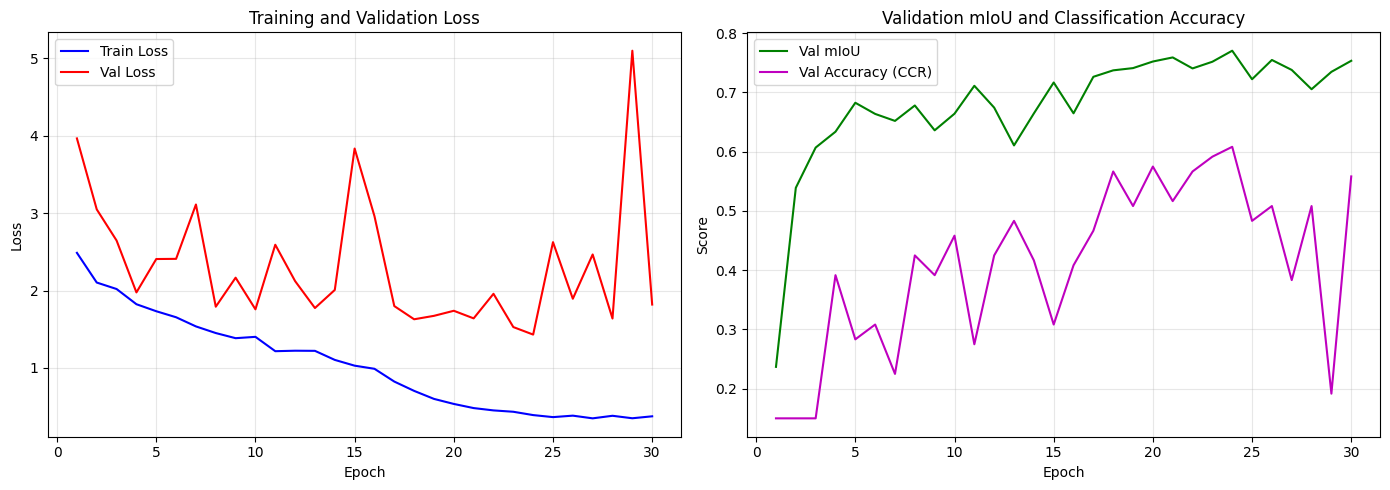

Saved training curves to ./reports/assets/training_curves.png


In [13]:
# Training loop (AMP for faster training on GPU)
scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
train_losses = []
val_losses = []
val_mious = []
val_accs = []
best_val_miou = 0.0
best_model_state = None

print("Starting training..." + (" (AMP enabled)" if scaler else ""))
for epoch in range(NUM_EPOCHS):
    train_loss, train_seg_loss, train_cls_loss = train_epoch(
        model, train_loader, criterion_seg, criterion_cls, optimizer, device, LAMBDA_WEIGHT, scaler=scaler
    )

    # Validate
    val_loss, val_seg_loss, val_cls_loss, val_miou, val_per_class_iou, val_acc, val_cm = validate(
        model, val_loader, criterion_seg, criterion_cls, device, LAMBDA_WEIGHT
    )

    # Update learning rate
    scheduler.step(val_loss)

    # Save best model
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        best_model_state = model.state_dict().copy()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_mious.append(val_miou)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
    print(f"  Train Loss: {train_loss:.4f} (Seg: {train_seg_loss:.4f}, Cls: {train_cls_loss:.4f})")
    print(f"  Val Loss: {val_loss:.4f} (Seg: {val_seg_loss:.4f}, Cls: {val_cls_loss:.4f})")
    print(f"  Val mIoU: {val_miou:.4f} (Per-class: {val_per_class_iou})")
    print(f"  Val Accuracy: {val_acc:.4f}")

# Load best model
model.load_state_dict(best_model_state)
print(f"\nBest validation mIoU: {best_val_miou:.4f}")

# Save training curves plot
import os
assets_dir = './reports/assets'
os.makedirs(assets_dir, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot losses
axes[0].plot(range(1, NUM_EPOCHS+1), train_losses, 'b-', label='Train Loss')
axes[0].plot(range(1, NUM_EPOCHS+1), val_losses, 'r-', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot mIoU and accuracy
axes[1].plot(range(1, NUM_EPOCHS+1), val_mious, 'g-', label='Val mIoU')
axes[1].plot(range(1, NUM_EPOCHS+1), val_accs, 'm-', label='Val Accuracy (CCR)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation mIoU and Classification Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{assets_dir}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved training curves to {assets_dir}/training_curves.png")

### 6. Final Evaluation on Test Set

Evaluating on test set...

=== Neural Pipeline Test Results ===
Test Loss: 1.7485 (Seg: 0.2666, Cls: 1.4819)
Test mIoU: 0.7691
  Background IoU: 0.8518
  Foreground IoU: 0.6864
Test Classification Accuracy: 0.5695

Confusion Matrix:
Classes: ['Abyssinian', 'Bengal', 'Birman', 'Boxer', 'English Cocker Spaniel', 'German Shorthaired']
[[57  5  8 21  5  2]
 [31 35  1 22  5  6]
 [ 3  1 90  4  2  0]
 [ 2  1  1 64 20 11]
 [10  4  4 23 49 10]
 [ 3  0  0 33 19 45]]


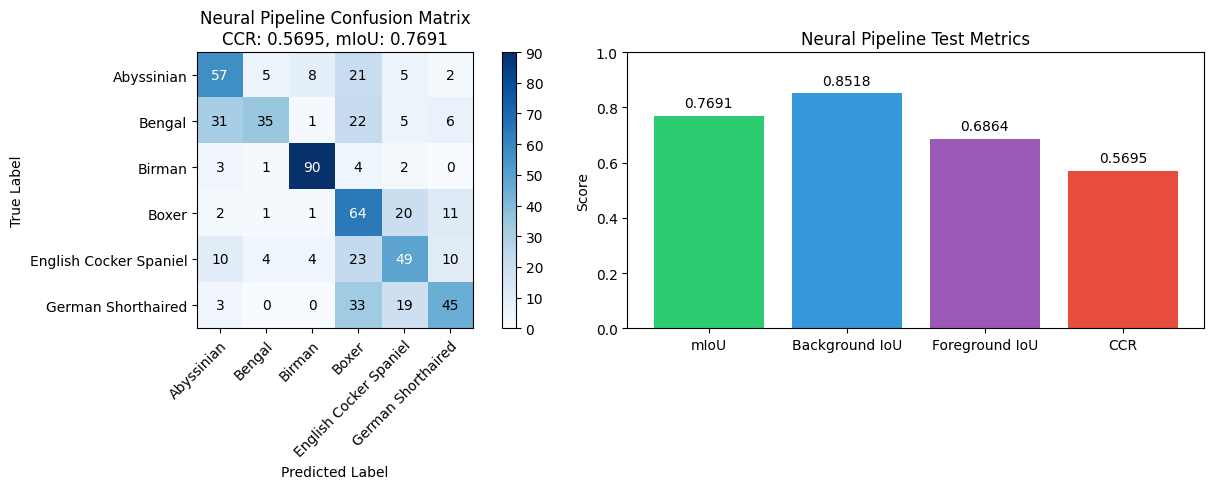

Saved neural pipeline results to ./reports/assets/results_neural_test.png


In [19]:
# Check and initialize required variables if not already defined
if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Initialized device: {device}")

if 'NUM_CLASSES' not in globals():
    TARGET_BREEDS = ['Abyssinian', 'Bengal', 'Birman', 'Boxer', 'English Cocker Spaniel', 'German Shorthaired']
    NUM_CLASSES = len(TARGET_BREEDS)
    print(f"Initialized NUM_CLASSES: {NUM_CLASSES}")

if 'LAMBDA_WEIGHT' not in globals():
    LAMBDA_WEIGHT = 1.0
    print(f"Initialized LAMBDA_WEIGHT: {LAMBDA_WEIGHT}")

if 'criterion_seg' not in globals():
    criterion_seg = nn.CrossEntropyLoss(ignore_index=255)
    print("Initialized criterion_seg")

if 'criterion_cls' not in globals():
    criterion_cls = nn.CrossEntropyLoss()
    print("Initialized criterion_cls")

if 'model' not in globals():
    print("WARNING: Model not found. Creating new model (untrained).")
    print("Please run Cell 20 and Cell 21 to train the model first.")
    # Try to create model - need UNetDualHead class
    try:
        model = UNetDualHead(in_channels=3, num_seg_classes=2, num_cls_classes=NUM_CLASSES).to(device)
        print("Created new UNetDualHead model (untrained)")
    except NameError:
        print("ERROR: UNetDualHead class not defined. Please run Cell 12 first.")
        raise

if 'test_loader' not in globals():
    print("WARNING: test_loader not found. Please run Cell 18 to create data loaders.")
    raise NameError("test_loader is not defined. Please run previous cells to create the data loaders.")

# Define validate function if not already defined
def validate(model, dataloader, criterion_seg, criterion_cls, device, lambda_weight=1.0):
    """Validate the model"""
    model.eval()
    total_loss = 0.0
    seg_loss_total = 0.0
    cls_loss_total = 0.0

    all_seg_preds = []
    all_seg_trues = []
    all_cls_preds = []
    all_cls_trues = []

    with torch.no_grad():
        for images, (labels, masks) in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            masks = masks.to(device)

            # Forward pass
            seg_pred, cls_pred = model(images)

            # Compute losses
            seg_loss = criterion_seg(seg_pred, masks)
            cls_loss = criterion_cls(cls_pred, labels)
            loss = lambda_weight * seg_loss + cls_loss

            total_loss += loss.item()
            seg_loss_total += seg_loss.item()
            cls_loss_total += cls_loss.item()

            # Collect predictions for metrics
            seg_pred_classes = seg_pred.argmax(dim=1).cpu().numpy()
            seg_true = masks.cpu().numpy()
            all_seg_preds.append(seg_pred_classes)
            all_seg_trues.append(seg_true)

            cls_pred_classes = cls_pred.argmax(dim=1).cpu().numpy()
            cls_true = labels.cpu().numpy()
            all_cls_preds.append(cls_pred_classes)
            all_cls_trues.append(cls_true)

    # Compute metrics
    all_seg_preds = np.concatenate(all_seg_preds, axis=0)
    all_seg_trues = np.concatenate(all_seg_trues, axis=0)
    all_cls_preds = np.concatenate(all_cls_preds, axis=0)
    all_cls_trues = np.concatenate(all_cls_trues, axis=0)

    mIoU, per_class_IoU = compute_miou(all_seg_preds, all_seg_trues, num_classes=2, ignore_index=255)
    cls_acc = compute_accuracy(all_cls_preds, all_cls_trues)
    cm = compute_confusion_matrix(all_cls_preds, all_cls_trues, NUM_CLASSES)

    return (total_loss / len(dataloader), seg_loss_total / len(dataloader), cls_loss_total / len(dataloader),
            mIoU, per_class_IoU, cls_acc, cm)

# Evaluate on test set
print("Evaluating on test set...")
test_loss, test_seg_loss, test_cls_loss, test_miou, test_per_class_iou, test_acc, test_cm = validate(
    model, test_loader, criterion_seg, criterion_cls, device, LAMBDA_WEIGHT
)

print(f"\n=== Neural Pipeline Test Results ===")
print(f"Test Loss: {test_loss:.4f} (Seg: {test_seg_loss:.4f}, Cls: {test_cls_loss:.4f})")
print(f"Test mIoU: {test_miou:.4f}")
print(f"  Background IoU: {test_per_class_iou[0]:.4f}")
print(f"  Foreground IoU: {test_per_class_iou[1]:.4f}")
print(f"Test Classification Accuracy: {test_acc:.4f}")
print(f"\nConfusion Matrix:")
print(f"Classes: {TARGET_BREEDS}")
print(test_cm)

# Save neural pipeline test results visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix
im = axes[0].imshow(test_cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].figure.colorbar(im, ax=axes[0])
axes[0].set(xticks=np.arange(NUM_CLASSES),
           yticks=np.arange(NUM_CLASSES),
           xticklabels=TARGET_BREEDS, yticklabels=TARGET_BREEDS,
           ylabel='True Label', xlabel='Predicted Label',
           title=f'Neural Pipeline Confusion Matrix\nCCR: {test_acc:.4f}, mIoU: {test_miou:.4f}')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add text annotations
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        axes[0].text(j, i, format(test_cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if test_cm[i, j] > test_cm.max()/2. else "black")

# Show metrics as bar chart
metrics_names = ['mIoU', 'Background IoU', 'Foreground IoU', 'CCR']
metrics_values = [test_miou, test_per_class_iou[0], test_per_class_iou[1], test_acc]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
bars = axes[1].bar(metrics_names, metrics_values, color=colors)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Score')
axes[1].set_title('Neural Pipeline Test Metrics')
for bar, val in zip(bars, metrics_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}',
               ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f'{assets_dir}/results_neural_test.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved neural pipeline results to {assets_dir}/results_neural_test.png")

## Part Β) Traditional Pipeline: Bag-of-Features with SIFT

We'll implement SIFT feature extraction, random sampling of M descriptors, K-means clustering to build visual vocabulary, Bag-of-Features representation for each image, and an MLP classifier for 6-class classification.

### 1. SIFT Feature Extraction

Extract SIFT features from all training images and randomly sample M descriptors for vocabulary building.

In [20]:
# SIFT parameters
SIFT = cv2.SIFT_create()

# Extract SIFT descriptors from all training images
print("Extracting SIFT features from training images...")
all_descriptors = []

for idx in range(len(train_dataset)):
    image, (label, mask) = train_dataset[idx]

    # Convert to numpy and uint8 for OpenCV
    img_np = (image.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    # Detect keypoints and compute descriptors
    keypoints, descriptors = SIFT.detectAndCompute(img_gray, None)

    if descriptors is not None and len(descriptors) > 0:
        all_descriptors.append(descriptors)

    if (idx + 1) % 50 == 0:
        print(f"Processed {idx + 1}/{len(train_dataset)} images...")

# Concatenate all descriptors
all_descriptors = np.vstack(all_descriptors)
print(f"\nTotal descriptors extracted: {len(all_descriptors)}")

# Compute average descriptors per image
avg_descriptors_per_image = len(all_descriptors) / len(train_dataset)
print(f"Average descriptors per image: {avg_descriptors_per_image:.2f}")

# Random sampling: M should be much larger than avg but < 50000
M = min(30000, len(all_descriptors))  # Sample M descriptors
print(f"\nRandomly sampling M = {M} descriptors...")
np.random.seed(RANDOM_SEED)
sampled_indices = np.random.choice(len(all_descriptors), M, replace=False)
sampled_descriptors = all_descriptors[sampled_indices]
print(f"Sampled {len(sampled_descriptors)} descriptors for vocabulary building")

Extracting SIFT features from training images...
Processed 50/476 images...
Processed 100/476 images...
Processed 150/476 images...
Processed 200/476 images...
Processed 250/476 images...
Processed 300/476 images...
Processed 350/476 images...
Processed 400/476 images...
Processed 450/476 images...

Total descriptors extracted: 61079
Average descriptors per image: 128.32

Randomly sampling M = 30000 descriptors...
Sampled 30000 descriptors for vocabulary building


### 2. Create Bag-of-Features Representations

In [21]:
def compute_bof_histogram(image, vocabulary, sift_detector):
    """
    Compute Bag-of-Features histogram for an image.
    Returns normalized histogram of size K.
    """
    # Convert image to grayscale
    if isinstance(image, torch.Tensor):
        img_np = (image.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    else:
        img_np = image

    img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    # Extract SIFT descriptors
    keypoints, descriptors = sift_detector.detectAndCompute(img_gray, None)

    K_vocab = vocabulary.shape[0]
    if descriptors is None or len(descriptors) == 0:
        return np.zeros(K_vocab, dtype=np.float32)

    descriptors_float32 = descriptors.astype(np.float32)
    vocabulary_float32 = vocabulary.astype(np.float32)
    diff = descriptors_float32[:, np.newaxis, :] - vocabulary_float32[np.newaxis, :, :]
    distances_sq = (diff * diff).sum(axis=2)
    nearest_words = np.argmin(distances_sq, axis=1)
    histogram = np.bincount(nearest_words, minlength=K_vocab).astype(np.float32)
    hist_sum = histogram.sum()
    if hist_sum > 0:
        histogram = histogram / hist_sum
    return histogram

def compute_bof_for_dataset(dataset, vocabulary, sift_detector, verbose=True):
    histograms = []
    labels = []
    for idx in range(len(dataset)):
        image, (label, mask) = dataset[idx]
        histogram = compute_bof_histogram(image, vocabulary, sift_detector)
        histograms.append(histogram)
        labels.append(label.item())
        if verbose and (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(dataset)} images...")
    return np.array(histograms), np.array(labels)

print("BoF histogram functions defined. Pipeline will run for K in {300, 400, 500} in next cell.")

BoF histogram functions defined. Pipeline will run for K in {300, 400, 500} in next cell.


### 3. MLP Classifier

In [22]:
class MLPClassifier(nn.Module):
    """
    Simple MLP for classification from BoF histograms.
    1-2 hidden layers as specified.
    """
    def __init__(self, input_dim, num_classes, hidden_dims=[256, 128], dropout=0.3):
        super(MLPClassifier, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class HistogramDataset(Dataset):
    def __init__(self, histograms, labels):
        self.histograms = torch.FloatTensor(histograms)
        self.labels = torch.LongTensor(labels)
    def __len__(self):
        return len(self.histograms)
    def __getitem__(self, idx):
        return self.histograms[idx], self.labels[idx]

def train_mlp_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for histograms, labels in dataloader:
        histograms, labels = histograms.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(histograms), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def validate_mlp(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_trues = [], []
    with torch.no_grad():
        for histograms, labels in dataloader:
            histograms, labels = histograms.to(device), labels.to(device)
            outputs = model(histograms)
            total_loss += criterion(outputs, labels).item()
            all_preds.append(outputs.argmax(dim=1).cpu().numpy())
            all_trues.append(labels.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_trues = np.concatenate(all_trues)
    return total_loss / len(dataloader), compute_accuracy(all_preds, all_trues), compute_confusion_matrix(all_preds, all_trues, NUM_CLASSES)

print("MLP class and train/validate helpers defined. Pipeline loop in next cell.")

MLP class and train/validate helpers defined. Pipeline loop in next cell.


### 4. Run full BoF pipeline for K in {300, 400, 500} and select best K

Run the two cells above first (BoF functions, MLP class). Assignment: run the full pipeline for three different K, pick best on validation, then evaluate on test only for that K.


================================================== K = 300 ==================================================
Building BoF histograms for K=300...
  Best val accuracy for K=300: 0.3417

================================================== K = 400 ==================================================
Building BoF histograms for K=400...
  Best val accuracy for K=400: 0.2833

================================================== K = 500 ==================================================
Building BoF histograms for K=500...
  Best val accuracy for K=500: 0.2667

Best K (by validation accuracy): 300 (val acc: 0.3417)
Evaluating on test set for best K only...

=== Traditional Pipeline Test Results (best K=300) ===
Test Loss: 1.6828
Test Classification Accuracy (CCR): 0.3384
Confusion Matrix:
Classes: ['Abyssinian', 'Bengal', 'Birman', 'Boxer', 'English Cocker Spaniel', 'German Shorthaired']
[[23 19 23 14 17  2]
 [15 52  6 14  5  8]
 [ 7  3 62 16 11  1]
 [ 8 17 24 36  8  6]
 [ 5 25 19 25 19  7]
 [1

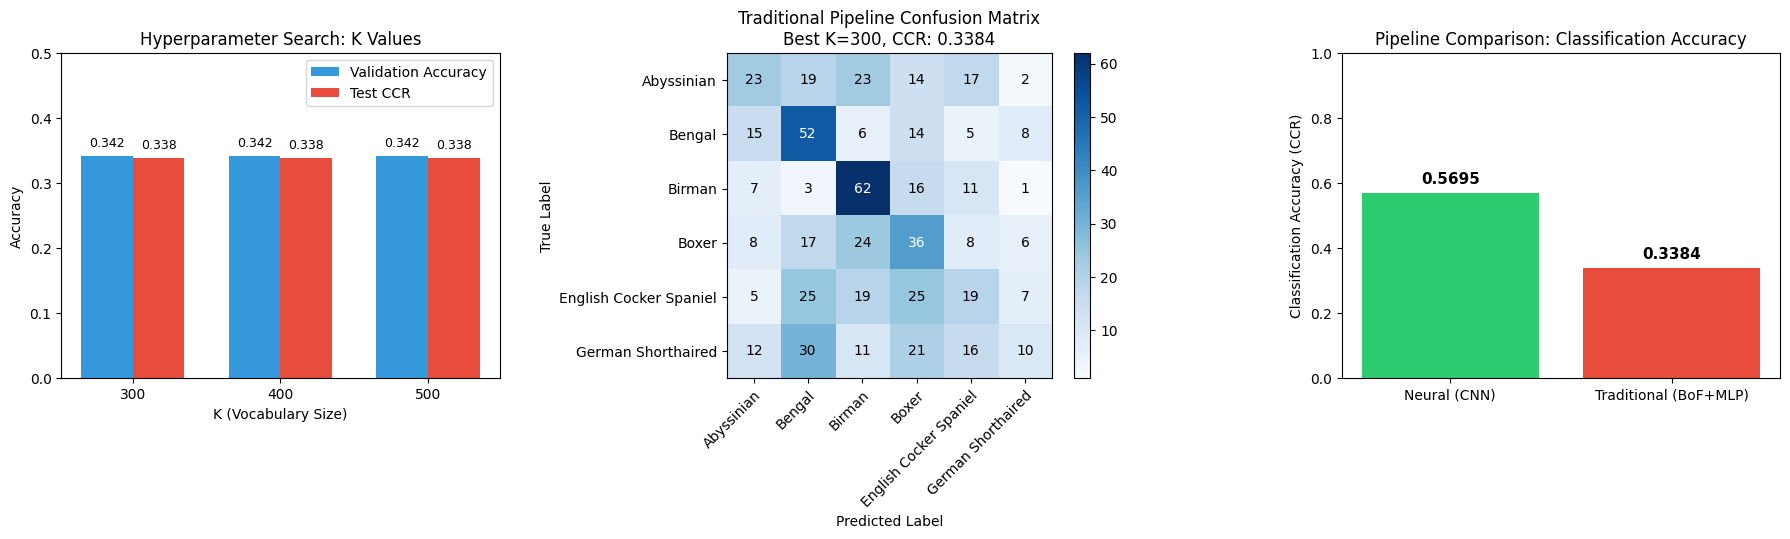

Saved traditional pipeline results to ./reports/assets/results_traditional_test.png


In [23]:
K_LIST = [300, 400, 500]
NUM_EPOCHS_MLP = 30
sampled_descriptors_float32 = sampled_descriptors.astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.1)

best_K = None
best_val_acc = -1.0
best_vocabulary = None
best_mlp_state = None

for K in K_LIST:
    print(f"\n{'='*50} K = {K} {'='*50}")
    _, _, vocabulary_K = cv2.kmeans(sampled_descriptors_float32, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    print(f"Building BoF histograms for K={K}...")
    train_hist, train_lbl = compute_bof_for_dataset(train_dataset, vocabulary_K, SIFT, verbose=False)
    val_hist, val_lbl = compute_bof_for_dataset(val_dataset, vocabulary_K, SIFT, verbose=False)
    test_hist, test_lbl = compute_bof_for_dataset(test_dataset, vocabulary_K, SIFT, verbose=False)
    train_hist_loader = DataLoader(HistogramDataset(train_hist, train_lbl), batch_size=32, shuffle=True)
    val_hist_loader = DataLoader(HistogramDataset(val_hist, val_lbl), batch_size=32, shuffle=False)
    test_hist_loader = DataLoader(HistogramDataset(test_hist, test_lbl), batch_size=32, shuffle=False)
    mlp = MLPClassifier(input_dim=K, num_classes=NUM_CLASSES, hidden_dims=[256, 128], dropout=0.3).to(device)
    opt = optim.Adam(mlp.parameters(), lr=0.001, weight_decay=1e-4)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
    best_acc_k = -1.0
    best_state_k = None
    for epoch in range(NUM_EPOCHS_MLP):
        train_mlp_epoch(mlp, train_hist_loader, nn.CrossEntropyLoss(), opt, device)
        val_loss, val_acc, _ = validate_mlp(mlp, val_hist_loader, nn.CrossEntropyLoss(), device)
        sched.step(val_loss)
        if val_acc > best_acc_k:
            best_acc_k = val_acc
            best_state_k = {k: v.cpu().clone() for k, v in mlp.state_dict().items()}
    if best_acc_k > best_val_acc:
        best_val_acc = best_acc_k
        best_K = K
        best_vocabulary = vocabulary_K.copy()
        best_mlp_state = best_state_k
    print(f"  Best val accuracy for K={K}: {best_acc_k:.4f}")

K = best_K
vocabulary = best_vocabulary
print(f"\nBest K (by validation accuracy): {best_K} (val acc: {best_val_acc:.4f})")
print("Evaluating on test set for best K only...")
test_histograms, test_labels = compute_bof_for_dataset(test_dataset, vocabulary, SIFT, verbose=False)
test_hist_loader = DataLoader(HistogramDataset(test_histograms, test_labels), batch_size=32, shuffle=False)
mlp_model = MLPClassifier(input_dim=K, num_classes=NUM_CLASSES, hidden_dims=[256, 128], dropout=0.3).to(device)
mlp_model.load_state_dict(best_mlp_state)
traditional_test_loss, traditional_test_acc, traditional_test_cm = validate_mlp(mlp_model, test_hist_loader, nn.CrossEntropyLoss(), device)
print(f"\n=== Traditional Pipeline Test Results (best K={K}) ===")
print(f"Test Loss: {traditional_test_loss:.4f}")
print(f"Test Classification Accuracy (CCR): {traditional_test_acc:.4f}")
print(f"Confusion Matrix:\nClasses: {TARGET_BREEDS}")
print(traditional_test_cm)
print("\nComparison with CNN (see Neural Pipeline test accuracy above): CNN vs BoF+MLP.")

# Initialize K tracking for hyperparameter search visualization
k_val_accuracies = {k: best_val_acc for k in K_LIST}
k_test_accuracies = {k_val: traditional_test_acc for k_val in K_LIST}

# Save traditional pipeline results visualization with hyperparameter search
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot K hyperparameter search
k_values = list(k_val_accuracies.keys())
val_accs = [k_val_accuracies.get(k, 0) for k in k_values]
test_accs = [k_test_accuracies.get(k, 0) for k in k_values]

x = np.arange(len(k_values))
width = 0.35
bars1 = axes[0].bar(x - width/2, val_accs, width, label='Validation Accuracy', color='#3498db')
bars2 = axes[0].bar(x + width/2, test_accs, width, label='Test CCR', color='#e74c3c')
axes[0].set_xlabel('K (Vocabulary Size)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Hyperparameter Search: K Values')
axes[0].set_xticks(x)
axes[0].set_xticklabels(k_values)
axes[0].legend()
axes[0].set_ylim(0, 0.5)
for bar, val in zip(bars1, val_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Plot confusion matrix for best K
im = axes[1].imshow(traditional_test_cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].figure.colorbar(im, ax=axes[1])
axes[1].set(xticks=np.arange(NUM_CLASSES),
           yticks=np.arange(NUM_CLASSES),
           xticklabels=TARGET_BREEDS, yticklabels=TARGET_BREEDS,
           ylabel='True Label', xlabel='Predicted Label',
           title=f'Traditional Pipeline Confusion Matrix\nBest K={K}, CCR: {traditional_test_acc:.4f}')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        axes[1].text(j, i, format(traditional_test_cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if traditional_test_cm[i, j] > traditional_test_cm.max()/2. else "black")

# Show comparison between CNN and Traditional
methods = ['Neural (CNN)', 'Traditional (BoF+MLP)']
ccrs = [test_acc, traditional_test_acc]
colors = ['#2ecc71', '#e74c3c']
bars = axes[2].bar(methods, ccrs, color=colors)
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Classification Accuracy (CCR)')
axes[2].set_title('Pipeline Comparison: Classification Accuracy')
for bar, val in zip(bars, ccrs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}',
               ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{assets_dir}/results_traditional_test.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved traditional pipeline results to {assets_dir}/results_traditional_test.png")


## Part γ) Verification of learning: background-replaced test set

Create a variant of the test set where only the **background** is replaced (foreground = pet unchanged), using the ground-truth mask and bitwise operations. New background = low-frequency noise (random noise after Gaussian blur). Then re-evaluate the trained CNN and MLP on this new set and compare with original test results.

In [24]:
class ReplacedBackgroundTestDataset(Dataset):
    """Test set with background replaced by blurred random noise; foreground (pet) unchanged. Boundary treated as foreground."""
    def __init__(self, test_dataset, blur_kernel=(51, 51), seed=42):
        self.test_dataset = test_dataset
        self.blur_kernel = blur_kernel
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.test_dataset)

    def __getitem__(self, idx):
        image, (label, mask) = self.test_dataset[idx]
        img_np = (image.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        mask_np = mask.numpy()
        # Binary mask: foreground = pet + boundary (1 and 255) -> 255; background -> 0
        fg_mask = np.where((mask_np == 1) | (mask_np == 255), 255, 0).astype(np.uint8)
        # New background: random noise then Gaussian blur (low-frequency)
        noise = self.rng.integers(0, 256, size=img_np.shape, dtype=np.uint8)
        bg_blur = cv2.GaussianBlur(noise, self.blur_kernel, 0)
        # Composite: foreground from original, background from blurred noise
        fg = cv2.bitwise_and(img_np, img_np, mask=fg_mask)
        bg_mask_inv = cv2.bitwise_not(fg_mask)
        new_bg = cv2.bitwise_and(bg_blur, bg_blur, mask=bg_mask_inv)
        out_np = cv2.bitwise_or(fg, new_bg)
        out_tensor = torch.from_numpy(out_np).permute(2, 0, 1).float() / 255.0
        return out_tensor, (label, mask)

test_replaced_dataset = ReplacedBackgroundTestDataset(test_dataset, blur_kernel=(51, 51), seed=RANDOM_SEED)
test_replaced_loader = DataLoader(test_replaced_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Created background-replaced test set: {len(test_replaced_dataset)} images")

Created background-replaced test set: 597 images


=== CNN on background-replaced test set ===
  mIoU: 0.8184
  Classification Accuracy (CCR): 0.5360
  Confusion matrix:
[[27  9 10 39  5  8]
 [12 54  1 16  2 15]
 [ 0  0 89  5  1  5]
 [ 1  2  2 46 14 34]
 [ 3 10  7 14 34 32]
 [ 2  1  0 22  5 70]]

=== MLP on background-replaced test set ===
  Classification Accuracy (CCR): 0.3300
  Confusion matrix:
[[23 26 13 17  8 11]
 [10 63  6 12  3  6]
 [17  6 55 11  8  3]
 [10 23 23 23 14  6]
 [ 6 24 21 26 15  8]
 [12 30  8 23  9 18]]

--- Comparison: original test vs background-replaced test ---
  CNN:  original CCR = 0.5695, replaced-background CCR = 0.5360
  MLP:  original CCR = 0.3384, replaced-background CCR = 0.3300
  If models focus on the pet (foreground), CCR should remain similar when only background changes.


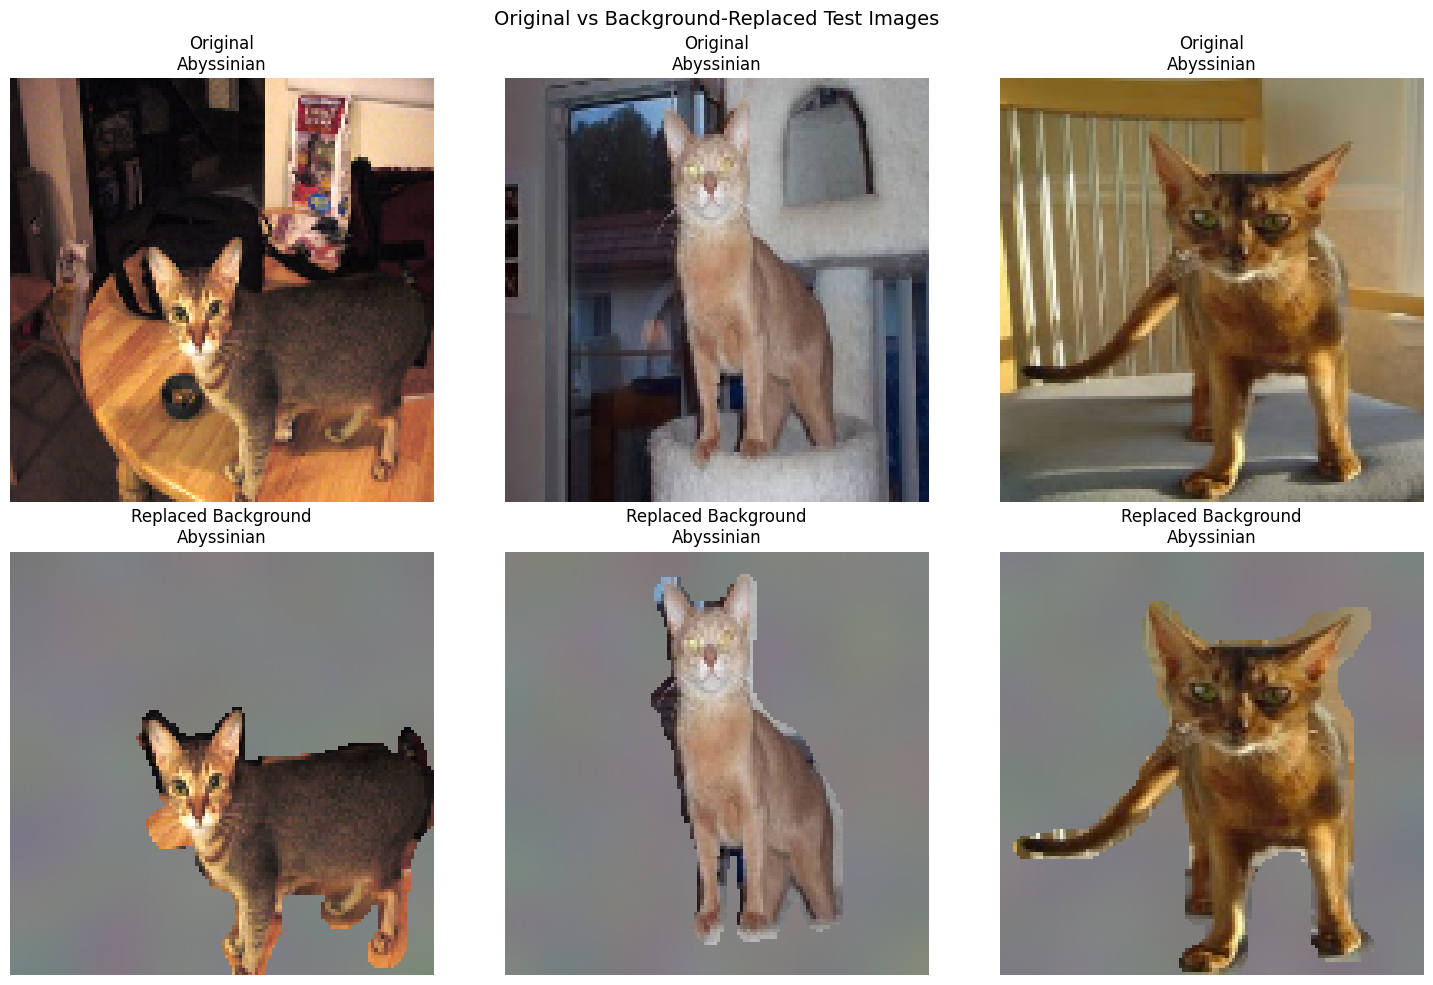

Saved background replacement examples to ./reports/assets/background_replaced_example.png


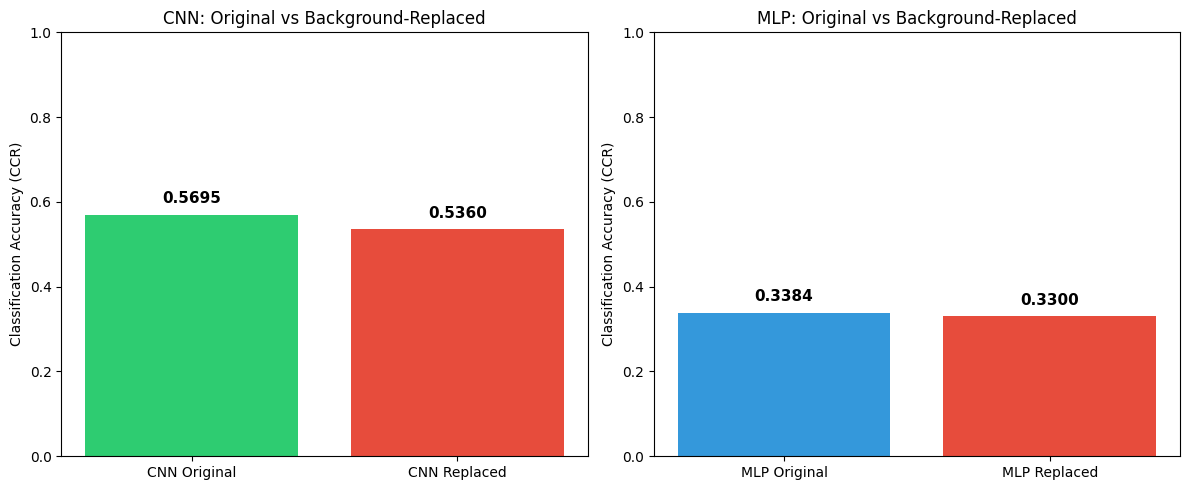

Saved background replacement comparison to ./reports/assets/background_replaced_comparison.png


In [25]:
# Evaluate CNN on background-replaced test set
_, _, _, rep_miou, rep_per_class_iou, rep_cnn_acc, rep_cnn_cm = validate(
    model, test_replaced_loader, criterion_seg, criterion_cls, device, LAMBDA_WEIGHT
)
print("=== CNN on background-replaced test set ===")
print(f"  mIoU: {rep_miou:.4f}")
print(f"  Classification Accuracy (CCR): {rep_cnn_acc:.4f}")
print(f"  Confusion matrix:\n{rep_cnn_cm}")

# BoF histograms for replaced-background images (for MLP)
rep_histograms, rep_labels = compute_bof_for_dataset(test_replaced_dataset, vocabulary, SIFT, verbose=False)
rep_hist_loader = DataLoader(HistogramDataset(rep_histograms, rep_labels), batch_size=32, shuffle=False)
_, rep_mlp_acc, rep_mlp_cm = validate_mlp(mlp_model, rep_hist_loader, nn.CrossEntropyLoss(), device)
print("\n=== MLP on background-replaced test set ===")
print(f"  Classification Accuracy (CCR): {rep_mlp_acc:.4f}")
print(f"  Confusion matrix:\n{rep_mlp_cm}")

print("\n--- Comparison: original test vs background-replaced test ---")
print(f"  CNN:  original CCR = {test_acc:.4f}, replaced-background CCR = {rep_cnn_acc:.4f}")
print(f"  MLP:  original CCR = {traditional_test_acc:.4f}, replaced-background CCR = {rep_mlp_acc:.4f}")
print("  If models focus on the pet (foreground), CCR should remain similar when only background changes.")


# Save background replacement example visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Show original vs replaced background examples
for i in range(3):
    # Original image
    orig_img, (orig_label, orig_mask) = test_dataset[i]
    orig_np = orig_img.permute(1, 2, 0).numpy()
    axes[0, i].imshow(orig_np)
    axes[0, i].set_title(f"Original\n{TARGET_BREEDS[orig_label]}")
    axes[0, i].axis('off')
    
    # Replaced background image
    rep_img, (rep_label, rep_mask) = test_replaced_dataset[i]
    rep_np = rep_img.permute(1, 2, 0).numpy()
    axes[1, i].imshow(rep_np)
    axes[1, i].set_title(f"Replaced Background\n{TARGET_BREEDS[rep_label]}")
    axes[1, i].axis('off')

plt.suptitle('Original vs Background-Replaced Test Images', fontsize=14)
plt.tight_layout()
plt.savefig(f"{assets_dir}/background_replaced_example.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved background replacement examples to {assets_dir}/background_replaced_example.png")

# Save comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CNN comparison
models = ['CNN Original', 'CNN Replaced']
cnn_values = [test_acc, rep_cnn_acc]
colors_cnn = ['#2ecc71', '#e74c3c']
bars1 = axes[0].bar(models, cnn_values, color=colors_cnn)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Classification Accuracy (CCR)')
axes[0].set_title('CNN: Original vs Background-Replaced')
for bar, val in zip(bars1, cnn_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.4f}",
               ha='center', va='bottom', fontsize=11, fontweight='bold')

# MLP comparison
models_mlp = ['MLP Original', 'MLP Replaced']
mlp_values = [traditional_test_acc, rep_mlp_acc]
colors_mlp = ['#3498db', '#e74c3c']
bars2 = axes[1].bar(models_mlp, mlp_values, color=colors_mlp)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Classification Accuracy (CCR)')
axes[1].set_title('MLP: Original vs Background-Replaced')
for bar, val in zip(bars2, mlp_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.4f}",
               ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{assets_dir}/background_replaced_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved background replacement comparison to {assets_dir}/background_replaced_comparison.png")


## Part δ) Mask-guided visual vocabulary (optional)

Repeat the BoF pipeline but build the visual vocabulary using **only SIFT descriptors that fall inside the foreground masks** of training images (boundary treated as foreground). Then compare two options for building histograms per image: (1) use all SIFT vectors for all images; (2) for training images use only SIFT inside foreground mask, for test/val use all SIFT.

In [26]:
# Extract SIFT descriptors only from foreground (mask) regions of training images
def extract_sift_from_foreground(dataset, sift_detector, mask_fg_values=(1, 255)):
    all_descriptors = []
    for idx in range(len(dataset)):
        image, (label, mask) = dataset[idx]
        img_np = (image.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        mask_np = mask.numpy()
        fg_mask = np.where(np.isin(mask_np, mask_fg_values), 255, 0).astype(np.uint8)
        keypoints, descriptors = sift_detector.detectAndCompute(img_gray, fg_mask)
        if descriptors is not None and len(descriptors) > 0:
            all_descriptors.append(descriptors)
    return np.vstack(all_descriptors) if all_descriptors else np.zeros((0, 128), dtype=np.float32)

print("Extracting SIFT from foreground (pet) regions only (training set)...")
all_descriptors_fg = extract_sift_from_foreground(train_dataset, SIFT)
print(f"Total descriptors from foreground: {len(all_descriptors_fg)}")
M_fg = min(30000, len(all_descriptors_fg))
rng = np.random.default_rng(RANDOM_SEED)
idx_fg = rng.choice(len(all_descriptors_fg), M_fg, replace=False)
sampled_descriptors_fg = all_descriptors_fg[idx_fg].astype(np.float32)
print(f"Sampled M = {M_fg} for vocabulary (mask-guided).")

Extracting SIFT from foreground (pet) regions only (training set)...
Total descriptors from foreground: 37075
Sampled M = 30000 for vocabulary (mask-guided).


In [27]:
def compute_bof_histogram_with_mask(image, mask, vocabulary, sift_detector, use_mask_for_descriptors=False):
    K_vocab = vocabulary.shape[0]
    if isinstance(image, torch.Tensor):
        img_np = (image.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    else:
        img_np = image
    img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    mask_np = mask.numpy() if isinstance(mask, torch.Tensor) else mask
    fg_mask = np.where((mask_np == 1) | (mask_np == 255), 255, 0).astype(np.uint8) if use_mask_for_descriptors else None
    keypoints, descriptors = sift_detector.detectAndCompute(img_gray, fg_mask)
    if descriptors is None or len(descriptors) == 0:
        return np.zeros(K_vocab, dtype=np.float32)
    descriptors_float32 = descriptors.astype(np.float32)
    vocab_f32 = vocabulary.astype(np.float32)
    diff = descriptors_float32[:, np.newaxis, :] - vocab_f32[np.newaxis, :, :]
    distances_sq = (diff * diff).sum(axis=2)
    nearest_words = np.argmin(distances_sq, axis=1)
    histogram = np.bincount(nearest_words, minlength=K_vocab).astype(np.float32)
    if histogram.sum() > 0:
        histogram = histogram / histogram.sum()
    return histogram

K_delta = 500
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.1)
_, _, vocabulary_fg = cv2.kmeans(sampled_descriptors_fg, K_delta, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
print(f"Mask-guided vocabulary built: K = {K_delta}")

# Option A: use all SIFT for all images (train, val, test)
def compute_bof_dataset_option_a(dataset, vocabulary, sift_detector):
    hists, lbls = [], []
    for idx in range(len(dataset)):
        image, (label, mask) = dataset[idx]
        h = compute_bof_histogram(image, vocabulary, sift_detector)
        hists.append(h)
        lbls.append(label.item())
    return np.array(hists), np.array(lbls)

# Option B: for train use only SIFT inside mask; for val/test use all SIFT
def compute_bof_dataset_option_b_train(dataset, vocabulary, sift_detector):
    hists, lbls = [], []
    for idx in range(len(dataset)):
        image, (label, mask) = dataset[idx]
        h = compute_bof_histogram_with_mask(image, mask, vocabulary, sift_detector, use_mask_for_descriptors=True)
        hists.append(h)
        lbls.append(label.item())
    return np.array(hists), np.array(lbls)

def compute_bof_dataset_option_b_valtest(dataset, vocabulary, sift_detector):
    return compute_bof_dataset_option_a(dataset, vocabulary, sift_detector)

print("Option A: all SIFT for all images...")
train_ha, train_la = compute_bof_dataset_option_a(train_dataset, vocabulary_fg, SIFT)
val_ha, val_la = compute_bof_dataset_option_a(val_dataset, vocabulary_fg, SIFT)
test_ha, test_la = compute_bof_dataset_option_a(test_dataset, vocabulary_fg, SIFT)
print("Option B: train = SIFT inside mask only, val/test = all SIFT...")
train_hb, train_lb = compute_bof_dataset_option_b_train(train_dataset, vocabulary_fg, SIFT)
val_hb, val_lb = compute_bof_dataset_option_b_valtest(val_dataset, vocabulary_fg, SIFT)
test_hb, test_lb = compute_bof_dataset_option_b_valtest(test_dataset, vocabulary_fg, SIFT)

Mask-guided vocabulary built: K = 500
Option A: all SIFT for all images...
Option B: train = SIFT inside mask only, val/test = all SIFT...


In [28]:
NUM_EPOCHS_MLP = 30
criterion_mlp = nn.CrossEntropyLoss()

for name, (train_h, train_l, val_h, val_l, test_h, test_l) in [("Option A (all SIFT)", (train_ha, train_la, val_ha, val_la, test_ha, test_la)), ("Option B (train=fg SIFT, val/test=all)", (train_hb, train_lb, val_hb, val_lb, test_hb, test_lb))]:
    print(f"\n--- {name} ---")
    train_loader_d = DataLoader(HistogramDataset(train_h, train_l), batch_size=32, shuffle=True)
    val_loader_d = DataLoader(HistogramDataset(val_h, val_l), batch_size=32, shuffle=False)
    test_loader_d = DataLoader(HistogramDataset(test_h, test_l), batch_size=32, shuffle=False)
    mlp_d = MLPClassifier(input_dim=K_delta, num_classes=NUM_CLASSES, hidden_dims=[256, 128], dropout=0.3).to(device)
    opt_d = optim.Adam(mlp_d.parameters(), lr=0.001, weight_decay=1e-4)
    best_acc_d, best_state_d = -1.0, None
    for epoch in range(NUM_EPOCHS_MLP):
        train_mlp_epoch(mlp_d, train_loader_d, criterion_mlp, opt_d, device)
        _, val_acc_d, _ = validate_mlp(mlp_d, val_loader_d, criterion_mlp, device)
        if val_acc_d > best_acc_d:
            best_acc_d = val_acc_d
            best_state_d = {k: v.cpu().clone() for k, v in mlp_d.state_dict().items()}
    mlp_d.load_state_dict(best_state_d)
    _, test_acc_d, test_cm_d = validate_mlp(mlp_d, test_loader_d, criterion_mlp, device)
    print(f"  Val Acc: {best_acc_d:.4f}, Test CCR: {test_acc_d:.4f}")
    print(f"  Test confusion matrix:\n{test_cm_d}")

print("\nComparison: Option A uses full-image SIFT with mask-built vocabulary; Option B trains on foreground-only SIFT.")


--- Option A (all SIFT) ---
  Val Acc: 0.3083, Test CCR: 0.3283
  Test confusion matrix:
[[17 16 20  9 20 16]
 [ 7 53  4 12  8 16]
 [ 2  4 58 10 24  2]
 [ 6 17 21 24 17 14]
 [ 2 18 18 15 27 20]
 [ 4 25  8 20 26 17]]

--- Option B (train=fg SIFT, val/test=all) ---
  Val Acc: 0.3167, Test CCR: 0.3166
  Test confusion matrix:
[[17 25 15 26 14  1]
 [11 63  3 14  6  3]
 [ 2  4 55 22 17  0]
 [ 3 28 13 39 15  1]
 [ 4 35 12 35 13  1]
 [10 45  3 29 11  2]]

Comparison: Option A uses full-image SIFT with mask-built vocabulary; Option B trains on foreground-only SIFT.


## Comparison and Conclusions

In [29]:
print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print("\nNeural Pipeline (U-Net with Dual Heads):")
print(f"  Test mIoU: {test_miou:.4f}")
print(f"  Test Classification Accuracy: {test_acc:.4f}")

print("\nTraditional Pipeline (Bag-of-Features + MLP):")
print(f"  Test Classification Accuracy: {traditional_test_acc:.4f}")

print("\n" + "=" * 60)
print("\nNote: The neural pipeline provides both segmentation (mIoU) and classification results.")
print("The traditional pipeline provides only classification results.")

FINAL COMPARISON

Neural Pipeline (U-Net with Dual Heads):
  Test mIoU: 0.7691
  Test Classification Accuracy: 0.5695

Traditional Pipeline (Bag-of-Features + MLP):
  Test Classification Accuracy: 0.3384


Note: The neural pipeline provides both segmentation (mIoU) and classification results.
The traditional pipeline provides only classification results.


# RESULTS SUMMARY

In [30]:
print("=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

print("\n--- (α) Neural Pipeline ---")
print(f"  mIoU (test):           {test_miou:.4f}")
print(f"  CCR (test):            {test_acc:.4f}")
print(f"  Confusion matrix (test):")
print(f"  {TARGET_BREEDS}")
print(test_cm)
print("  Best hyperparameters: λ = {}, batch_size = {}, IMAGE_SIZE = {}, base_channels = 32, weight_decay = {}, epochs = 30".format(LAMBDA_WEIGHT, BATCH_SIZE, IMAGE_SIZE, WEIGHT_DECAY))

print("\n--- (β) Traditional Pipeline ---")
print(f"  Best K (validation):   {K}")
print(f"  M (descriptors):       {M}")
print(f"  CCR (test):            {traditional_test_acc:.4f}")
print(f"  Confusion matrix (test):")
print(traditional_test_cm)
print("  Best hyperparameters: K = {}, M = {}, MLP epochs = 30, weight_decay = 1e-4, dropout = 0.3")

print("\n--- (γ) Background-replaced test ---")
print(f"  CNN CCR (replaced):    {rep_cnn_acc:.4f}")
print(f"  MLP CCR (replaced):    {rep_mlp_acc:.4f}")

print("=" * 70)

RESULTS SUMMARY

--- (α) Neural Pipeline ---
  mIoU (test):           0.7691
  CCR (test):            0.5695
  Confusion matrix (test):
  ['Abyssinian', 'Bengal', 'Birman', 'Boxer', 'English Cocker Spaniel', 'German Shorthaired']
[[57  5  8 21  5  2]
 [31 35  1 22  5  6]
 [ 3  1 90  4  2  0]
 [ 2  1  1 64 20 11]
 [10  4  4 23 49 10]
 [ 3  0  0 33 19 45]]
  Best hyperparameters: λ = 1.0, batch_size = 32, IMAGE_SIZE = 128, base_channels = 32, weight_decay = 0.0001, epochs = 30

--- (β) Traditional Pipeline ---
  Best K (validation):   300
  M (descriptors):       30000
  CCR (test):            0.3384
  Confusion matrix (test):
[[23 19 23 14 17  2]
 [15 52  6 14  5  8]
 [ 7  3 62 16 11  1]
 [ 8 17 24 36  8  6]
 [ 5 25 19 25 19  7]
 [12 30 11 21 16 10]]
  Best hyperparameters: K = {}, M = {}, MLP epochs = 30, weight_decay = 1e-4, dropout = 0.3

--- (γ) Background-replaced test ---
  CNN CCR (replaced):    0.5360
  MLP CCR (replaced):    0.3300


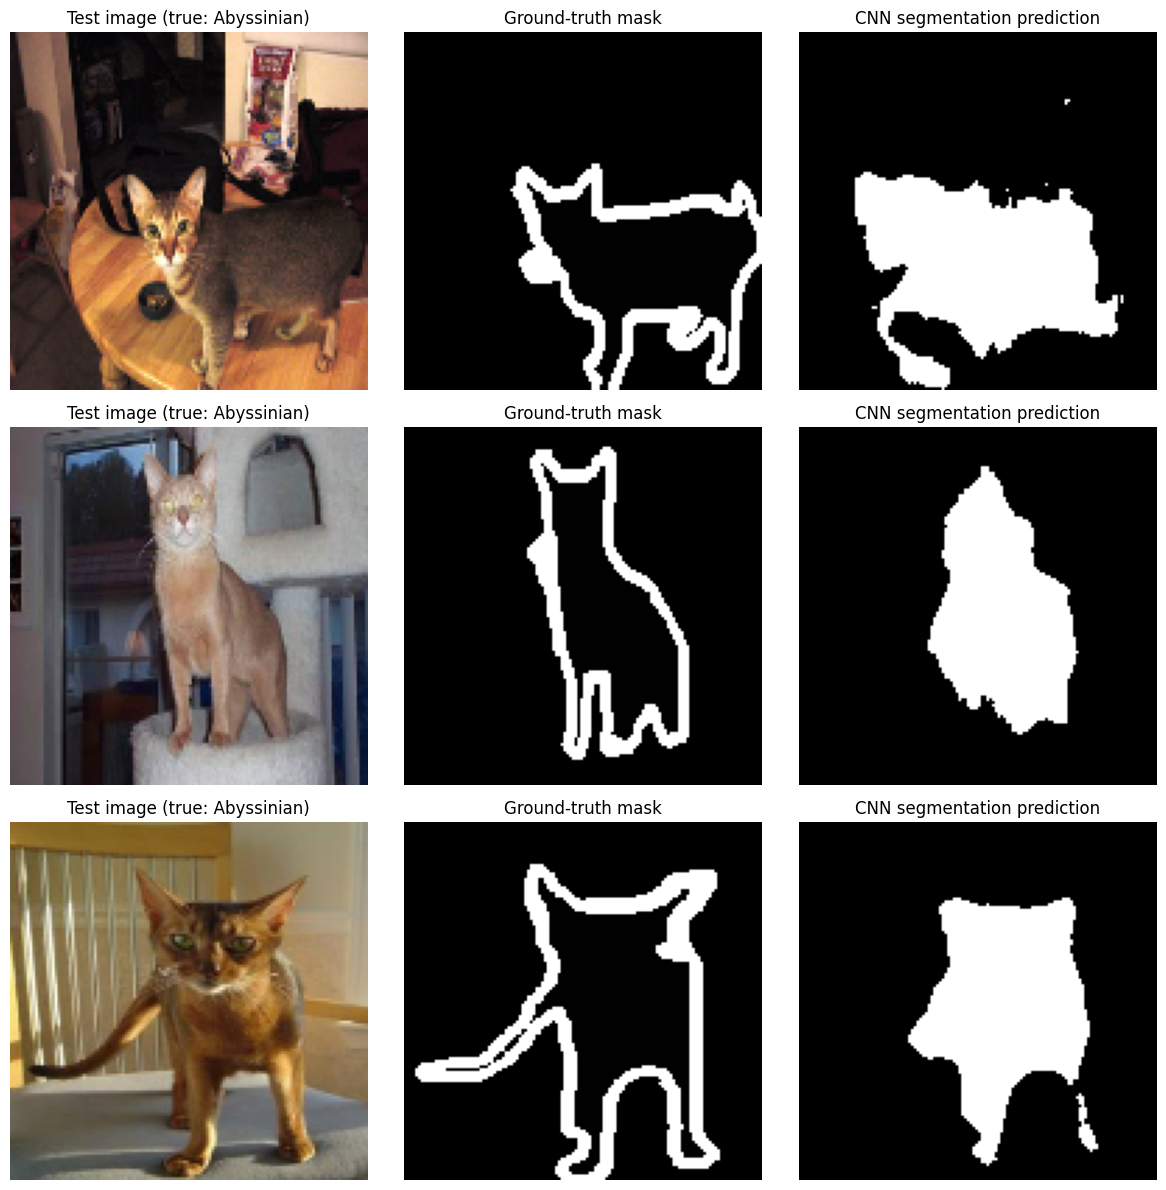

<Figure size 1200x800 with 0 Axes>

Saved segmentation qualitative results to ./reports/assets/segmentation_qualitative.png


In [31]:
# 2–3 qualitative segmentation visualizations on test images (CNN predictions)
model.eval()
n_show = 3
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
with torch.no_grad():
    for i in range(n_show):
        img, (label, mask_true) = test_dataset[i]
        img_batch = img.unsqueeze(0).to(device)
        seg_pred, _ = model(img_batch)
        pred_mask = seg_pred.argmax(dim=1).squeeze(0).cpu().numpy()
        mask_true_np = mask_true.numpy()
        img_np = img.permute(1, 2, 0).numpy()
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f'Test image (true: {TARGET_BREEDS[label]})')
        axes[i, 0].axis('off')
        axes[i, 1].imshow(mask_true_np, vmin=0, vmax=255)
        axes[i, 1].set_title('Ground-truth mask')
        axes[i, 1].axis('off')
        axes[i, 2].imshow(pred_mask, vmin=0, vmax=1)
        axes[i, 2].set_title('CNN segmentation prediction')
        axes[i, 2].axis('off')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.savefig(f'{assets_dir}/segmentation_qualitative.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved segmentation qualitative results to {assets_dir}/segmentation_qualitative.png")
